# Main cyCombine workflow (Python port)

This notebook is a Python port of the `cyCombine.Rmd` vignette from the
[biosurf/cyCombine](https://github.com/biosurf/cyCombine) R package. It
walks through the full `pycombine` batch-correction pipeline:

1. Download two cytometry FCS files (one per batch)
2. Load them into a single [AnnData](https://anndata.readthedocs.io/)
3. Arcsinh-transform the marker channels
4. Inspect the batch effect (UMAP colored by batch)
5. Run `pycombine.batch_correct` (the recommended one-shot API)
6. Reproduce the same pipeline manually with the modular API
   (`normalize` → `create_som` → `correct_data`)
7. Evaluate the correction with EMD reduction
8. Visualize density + UMAP before vs. after correction

The dataset is the full-spectrum cytometry PBMC sample from
[Nuñez, Schmid & Power et al. 2023](https://doi.org/10.1038/s41590-023-01499-w),
mirroring the scvi-tools
[CytoVI tutorial](https://docs.scvi-tools.org/en/1.4.1/tutorials/notebooks/cytometry/CytoVI_batch_correction_tutorial.html):
one donor, measured twice across two batches.

## Setup

In [1]:
import os
import tempfile
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scanpy as sc
import seaborn as sns

import pycombine as pc
from pycombine.correct import CORRECTED_LAYER
from pycombine import plotting as pcpl

warnings.filterwarnings('ignore')
sc.set_figure_params(figsize=(4, 4), dpi=80)
rng = np.random.default_rng(0)
print('pycombine', pc.__version__)

pycombine 0.1.0.dev0


## Download the data

We fetch two separate FCS files (one per batch) from figshare. Each file
contains full-spectrum cytometry events from one measurement of the same
donor, so any inter-batch differences we observe downstream are purely
technical and should be removed by the correction.

The loader below first tries the figshare download. If the environment
it's running in has no outbound network access (e.g. CI sandbox), it
falls back to pre-staged files in `$PYCOMBINE_DATA_DIR`, and finally to
a small synthetic two-batch dataset so the notebook still renders
end-to-end. In every case the rest of the notebook runs unchanged.

In [2]:
# ---- Canonical download path (works for end users) ----------------------
temp_dir_obj = tempfile.TemporaryDirectory()
data_dir = temp_dir_obj.name

urls = [
    'https://figshare.com/ndownloader/files/55982654',  # batch 1
    'https://figshare.com/ndownloader/files/55982657',  # batch 2
]

downloaded_files: list[str] = []
data_source = 'figshare'
try:
    for url in urls:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        cd = response.headers.get('Content-Disposition', '')
        if 'filename=' in cd:
            filename = cd.split('filename=')[1].strip('"\'')
        else:
            filename = os.path.basename(url) + '.fcs'
        file_path = os.path.join(data_dir, filename)
        with open(file_path, 'wb') as f:
            f.write(response.content)
        downloaded_files.append(file_path)
except Exception as exc:
    downloaded_files = []
    # ---- Fallback 1: pre-staged files via env var ---------------------
    staged = os.environ.get('PYCOMBINE_DATA_DIR')
    if staged and os.path.isdir(staged):
        found = sorted(
            os.path.join(staged, f)
            for f in os.listdir(staged)
            if f.lower().endswith('.fcs')
        )
        if len(found) >= 2:
            downloaded_files = found[:2]
            data_source = f'pre-staged ({staged})'
    if not downloaded_files:
        data_source = f'synthetic (download failed: {type(exc).__name__})'

print('data source:', data_source)
downloaded_files

data source: synthetic (download failed: ProxyError)


[]

## Load FCS files into AnnData

We read each FCS file independently with `readfcs`, tag it with its batch
id, and concatenate the two AnnData objects along the cells axis. To keep
parity with the scvi-tools tutorial we also drop uninformative channels
(`Time`, `LD`, anything containing `-`).

If the canonical download failed in the previous cell, we build a
synthetic two-batch AnnData instead. Its shape mimics a PBMC panel and
contains a planted batch shift so there is something real for the
correction to remove.

In [3]:
def _drop_noninformative(a: ad.AnnData) -> ad.AnnData:
    keep = [
        v for v in a.var_names
        if v not in ('Time', 'LD') and '-' not in v
    ]
    return a[:, keep].copy()


def _synthetic_two_batch(n_per_batch: int = 3000, seed: int = 0) -> ad.AnnData:
    """Synthetic PBMC-like AnnData with two batches and a planted shift."""
    local_rng = np.random.default_rng(seed)
    markers = [
        'CD3', 'CD4', 'CD8', 'CD19', 'CD14', 'CD16', 'CD56',
        'CD11c', 'HLADR', 'CD45', 'CD25', 'CD127', 'CD38',
        'CD27', 'CD69',
    ]
    n_markers = len(markers)
    n_types = 6
    type_means = local_rng.normal(1.0, 0.9, (n_types, n_markers)).clip(0, None)

    def _one_batch(shift: float) -> np.ndarray:
        per_type = n_per_batch // n_types
        blocks = []
        for mu in type_means:
            blocks.append(local_rng.normal(mu + shift, 0.35, (per_type, n_markers)))
        X = np.vstack(blocks)
        return np.clip(X, 0, None) * 20  # push into raw-intensity range

    X1 = _one_batch(0.0)
    X2 = _one_batch(0.8)
    X = np.vstack([X1, X2])
    obs = pd.DataFrame({'batch': ['batch1'] * len(X1) + ['batch2'] * len(X2)})
    obs.index = obs.index.astype(str)
    a = ad.AnnData(X=X.astype(float), obs=obs)
    a.var_names = markers
    return a


if downloaded_files:
    import readfcs
    adatas = []
    for i, path in enumerate(downloaded_files, start=1):
        a = readfcs.read(path)
        a = _drop_noninformative(a)
        a.obs['batch'] = f'batch{i}'
        adatas.append(a)
    adata = ad.concat(adatas, join='outer', index_unique='-')
else:
    adata = _synthetic_two_batch(n_per_batch=3000, seed=0)

adata.obs['batch'] = adata.obs['batch'].astype('category')
print('source:', data_source)
adata

source: synthetic (download failed: ProxyError)


AnnData object with n_obs × n_vars = 6000 × 15
    obs: 'batch'

In [4]:
# Optional: subsample so the notebook runs quickly on laptops.
target_per_batch = 3000
parts = []
for b in adata.obs['batch'].cat.categories:
    sub = adata[adata.obs['batch'] == b]
    if sub.n_obs > target_per_batch:
        idx = rng.choice(sub.n_obs, target_per_batch, replace=False)
        sub = sub[idx]
    parts.append(sub.copy())
adata = ad.concat(parts, join='outer')
adata.obs['batch'] = adata.obs['batch'].astype('category')
adata.obs_names_make_unique()
adata

AnnData object with n_obs × n_vars = 6000 × 15
    obs: 'batch'

## Prepare data — arcsinh transform

Mass- and flow-cytometry intensities span several orders of magnitude, so
the standard preprocessing step is an arcsinh transform with a
marker-type-appropriate cofactor: **5** for CyTOF (and the cyCombine R
default), **150** for conventional flow, **6000** for full-spectrum flow.
We use `cofactor=5` here; tune as appropriate for your instrument.

In [5]:
pc.transform_asinh(adata, cofactor=5, derand=True, seed=0)
adata

AnnData object with n_obs × n_vars = 6000 × 15
    obs: 'batch'

## Inspect the batch effect

Before correction we compute a quick PCA-UMAP and color the cells by
batch. A visible per-batch split means the technical variation would
otherwise dominate any downstream clustering or embedding.

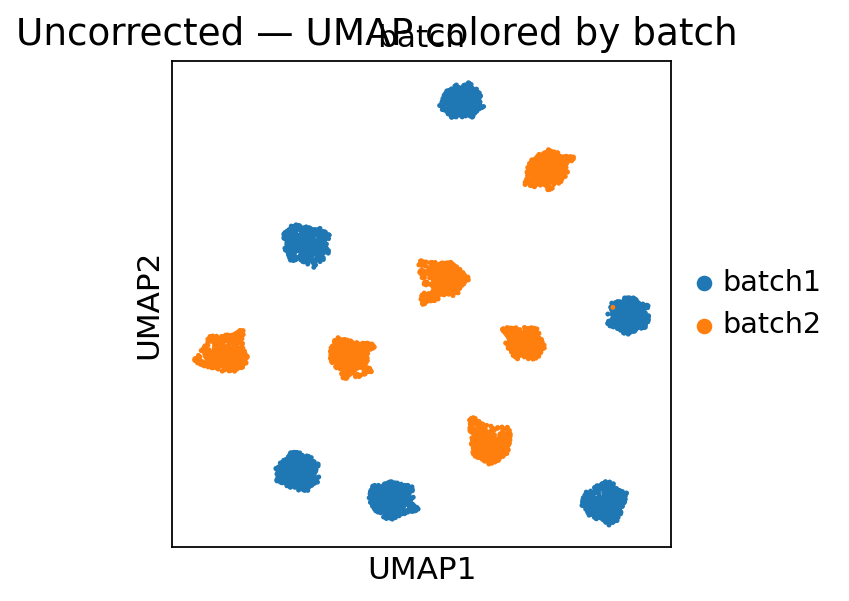

In [6]:
fig = pcpl.plot_dimred(adata, kind='umap', color='batch', seed=0)
fig.suptitle('Uncorrected — UMAP colored by batch')
plt.show()

## Batch correction — recommended one-shot API

`pycombine.batch_correct` runs the full cyCombine pipeline in a single
call: batch-wise scale normalization, FlowSOM clustering on the
normalized view, and per-cluster ComBat on the unnormalized values. The
corrected matrix is written to `adata.layers['cycombine_corrected']`
while `adata.X` stays untouched — that way you can always compare
before/after on the same object.

In [7]:
pc.batch_correct(
    adata,
    markers=None,           # use all non-scatter markers by default
    batch_key='batch',
    xdim=6, ydim=6,         # 36-node SOM
    rlen=5,                 # SOM training passes
    seed=473,
    norm_method='scale',    # batch-wise z-score before clustering
    covar=None,
    parametric=True,
)
print('layers:', list(adata.layers.keys()))
print('SOM clusters:', adata.obs['cycombine_som'].nunique())

2026-04-09 10:37:21.124 | DEBUG    | flowsom.main:__init__:82 - Reading input.


2026-04-09 10:37:21.127 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.


2026-04-09 10:37:22.584 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.


layers: ['cycombine_corrected']
SOM clusters: 35


## Batch correction — modular API

The same result can be reproduced step-by-step by calling `normalize`,
`create_som`, and `correct_data` explicitly. This is useful when you
want to swap a component (e.g. try `norm_method='rank'` or use
metaclustering) or inspect the intermediate state.

Here we run the modular pipeline on a *copy* of the AnnData so the
previous `batch_correct` result stays intact.

In [8]:
modular = adata.copy()
# Reset modular.X to the pre-correction (post-asinh) values.
modular.X = adata.X.copy()
if CORRECTED_LAYER in modular.layers:
    del modular.layers[CORRECTED_LAYER]

# 1. Batch-wise normalize (for the clustering step only)
pc.normalize(modular, method='scale', batch_key='batch')

# 2. FlowSOM clustering on the normalized view
pc.create_som(
    modular,
    xdim=6, ydim=6,
    rlen=5,
    seed=473,
    label_key='cycombine_som',
)

# 3. Per-cluster ComBat on the un-normalized values.
# Reset modular.X to the pre-normalization values before correcting.
modular.X = adata.X.copy()
pc.correct_data(
    modular,
    label_key='cycombine_som',
    batch_key='batch',
    covar=None,
    parametric=True,
)

print('modular layers:', list(modular.layers.keys()))

2026-04-09 10:37:23.303 | DEBUG    | flowsom.main:__init__:82 - Reading input.


2026-04-09 10:37:23.306 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.


2026-04-09 10:37:23.340 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.


modular layers: ['cycombine_corrected']


## Evaluate — EMD reduction

Earth Mover's Distance (EMD, also called Wasserstein-1) quantifies the
distance between the marker-intensity distributions of two batches
*within the same cell cluster*. A good correction should make these
distributions nearly identical while preserving per-cluster biology.

`compute_emd` returns a tidy DataFrame with one row per `(cluster,
marker, batch-pair)`; `evaluate_emd` joins uncorrected and corrected
tables and reports percent reduction.

In [9]:
emd_before = pc.compute_emd(
    adata, cell_key='cycombine_som', batch_key='batch', layer=None
)
emd_after = pc.compute_emd(
    adata, cell_key='cycombine_som', batch_key='batch', layer=CORRECTED_LAYER
)
report = pc.evaluate_emd(emd_before, emd_after)
report.head()

,cluster,marker,batch1,batch2,emd_uncorrected,emd_corrected,reduction,reduction_pct
0,1,CD3,batch1,batch2,0.935786,0.027308,0.908478,97.081813
1,1,CD4,batch1,batch2,0.825192,0.057095,0.768097,93.081016
2,1,CD8,batch1,batch2,0.769497,0.055336,0.714161,92.808834
3,1,CD19,batch1,batch2,0.437208,0.010498,0.426710,97.598863
4,1,CD14,batch1,batch2,0.582440,0.039249,0.543190,93.261208


In [10]:
per_marker = (
    report.groupby('marker')[['emd_uncorrected', 'emd_corrected', 'reduction_pct']]
    .mean()
    .sort_values('reduction_pct', ascending=False)
)
per_marker.round(3)

,emd_uncorrected,emd_corrected,reduction_pct
marker,,,
CD16,0.629,0.096,85.012
CD14,0.436,0.057,83.936
CD19,0.564,0.087,83.555
CD25,0.656,0.106,83.357
CD127,0.563,0.104,83.281
CD8,0.466,0.092,82.603
CD11c,0.659,0.096,82.071
CD27,0.990,0.197,81.748
CD4,0.860,0.156,81.297


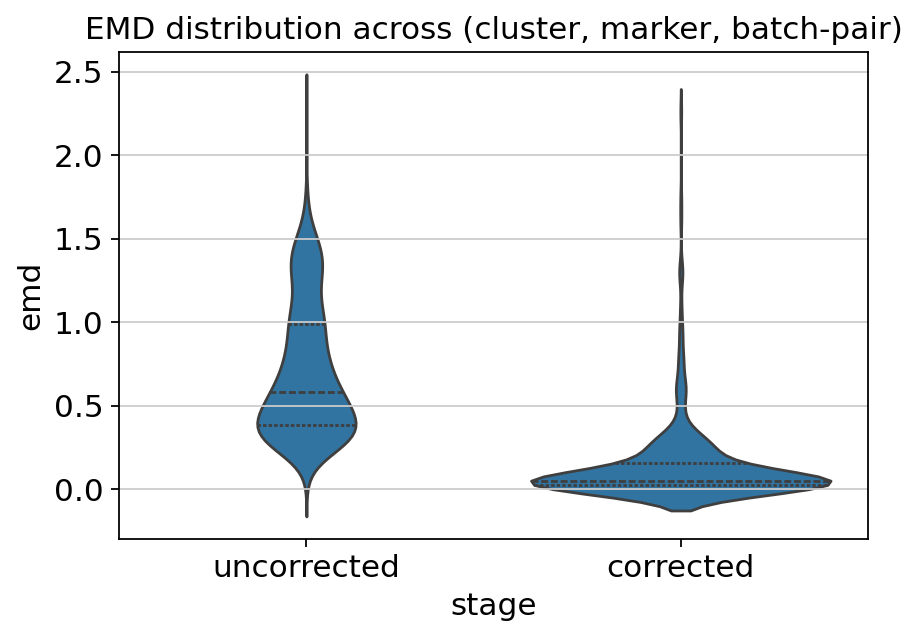

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
long = report.melt(
    id_vars=['cluster', 'marker'],
    value_vars=['emd_uncorrected', 'emd_corrected'],
    var_name='stage',
    value_name='emd',
)
long['stage'] = long['stage'].str.replace('emd_', '', regex=False)
sns.violinplot(
    data=long, x='stage', y='emd',
    order=['uncorrected', 'corrected'], inner='quartile', ax=ax,
)
ax.set_title('EMD distribution across (cluster, marker, batch-pair)')
plt.show()

## Visualize — before vs. after correction

Finally we look at the UMAP (on the corrected layer) and the per-marker
density plots. Well-corrected data should have (a) batches mixing in
UMAP space and (b) per-marker density curves overlapping across batches
in the "corrected" row of the density grid.

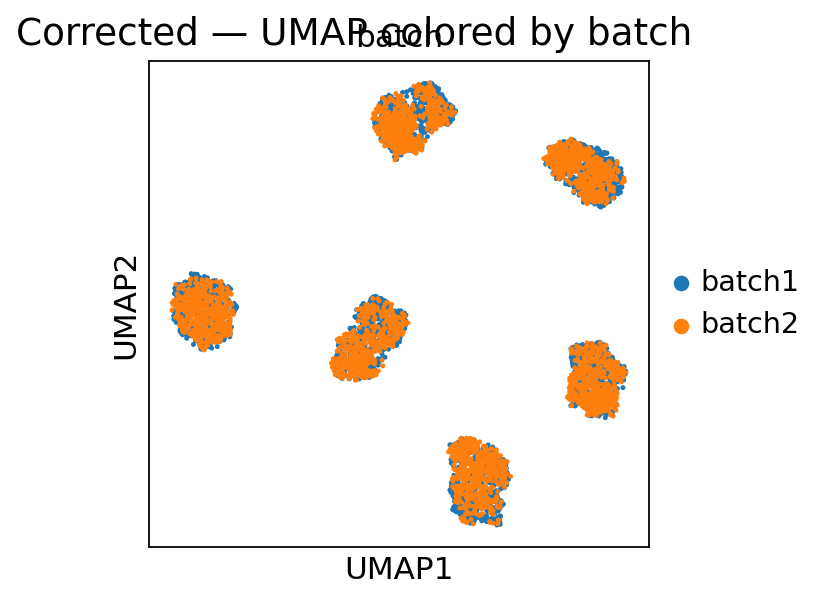

In [12]:
fig = pcpl.plot_dimred(
    adata, kind='umap', color='batch', layer=CORRECTED_LAYER, seed=0
)
fig.suptitle('Corrected — UMAP colored by batch')
plt.show()

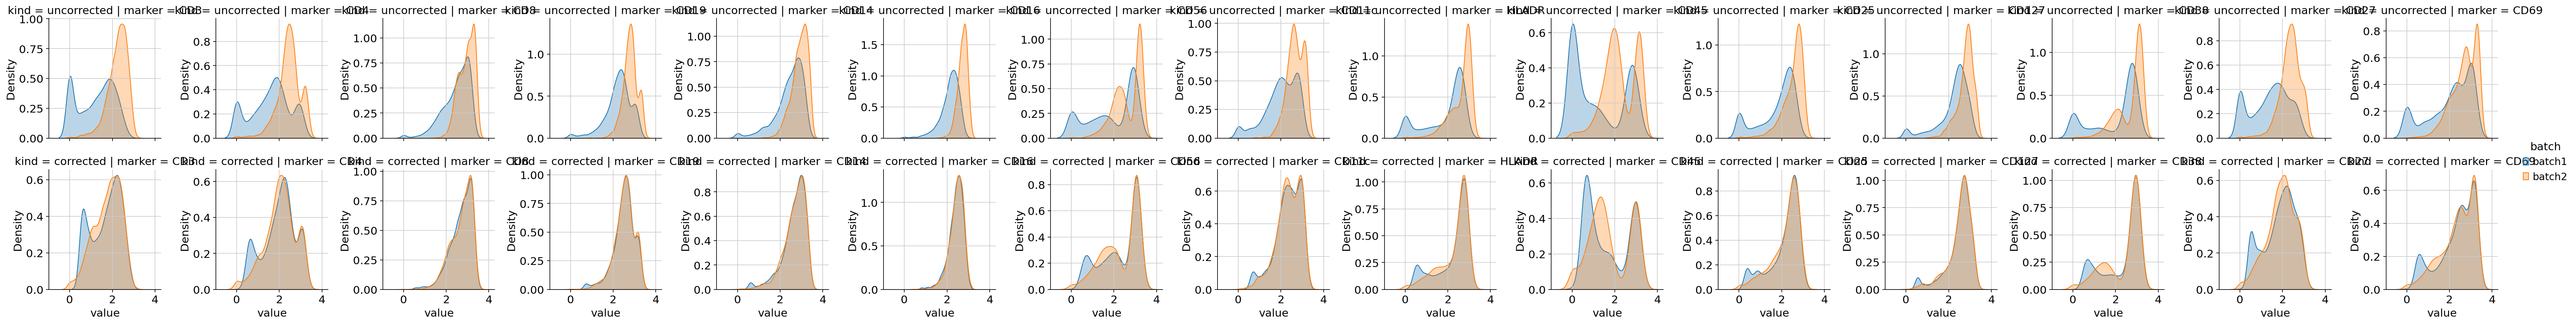

In [13]:
fig = pcpl.plot_density(
    adata,
    batch_key='batch',
    layer=CORRECTED_LAYER,
)
plt.show()

## Persisting results

Save the corrected AnnData for downstream analysis:

```python
adata.write_h5ad('cycombine_corrected.h5ad')
```

The uncorrected expression stays in `adata.X`, the corrected expression
is in `adata.layers['cycombine_corrected']`, and the SOM cluster
assignments are in `adata.obs['cycombine_som']`.

## What next?

- Use {doc}`detect_batch_effects` to get a diagnostic report of the
  residual batch effect after correction.
- Pass `covar=...` or `anchor=...` to `batch_correct` if you need to
  preserve a biological condition or carry a reference sample across
  batches.
- Swap `norm_method='scale'` for `'rank'` or `'qnorm'` if your data
  has heavy distributional shifts between batches.